# 测试集预测（加载最优模型权重）
本 notebook 从主训练 notebook 中独立出来，仅执行以下操作：
1. 导入库并定义模型结构
2. 加载测试数据并归一化
3. 加载已保存的 scaler 和最优模型权重
4. MC Dropout 预测
5. 逆归一化与模型评估
6. 结果可视化

In [1]:
# ============================================
# 1. 导入库 & 全局设置
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

# 绘图风格
plt.style.use('default')
plt.rcParams['font.family'] = ['Times New Roman', 'SimSun']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['axes.unicode_minus'] = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"设备: {DEVICE}")
print(f"PyTorch 版本: {torch.__version__}")

设备: cuda
PyTorch 版本: 2.1.0+cu121


In [2]:
# ============================================
# 2. 定义模型结构（必须与训练时完全一致）
# ============================================
class TCNBlock(nn.Module):
    """TCN块：因果卷积 + ReLU + Dropout + 残差连接"""
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super(TCNBlock, self).__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(
            in_channels, out_channels, kernel_size,
            padding=self.padding, dilation=dilation
        )
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        self.residual = (
            nn.Conv1d(in_channels, out_channels, 1)
            if in_channels != out_channels
            else nn.Identity()
        )

    def forward(self, x):
        out = self.conv(x)
        out = out[:, :, :-(self.conv.padding[0])]
        out = self.relu(out)
        out = self.dropout(out)
        return out + self.residual(x)


class SimpleAttention(nn.Module):
    """简单注意力机制"""
    def __init__(self, hidden_dim):
        super(SimpleAttention, self).__init__()
        self.attn_weights = nn.Parameter(torch.randn(hidden_dim, 1))

    def forward(self, x):
        scores = torch.matmul(x, self.attn_weights).squeeze(-1)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        return x * weights


class HybridModel(nn.Module):
    """TCN + Attention + LSTM 混合模型"""
    def __init__(self, input_size, hidden_size, output_size):
        super(HybridModel, self).__init__()
        tcn_layers = []
        channels = [input_size, 64, 64, 64, 64, 64]
        dilations = [1, 2, 4, 8, 16]
        for i in range(len(dilations)):
            tcn_layers.append(
                TCNBlock(channels[i], channels[i+1], kernel_size=3, dilation=dilations[i])
            )
        self.tcn = nn.Sequential(*tcn_layers)
        self.attention = SimpleAttention(64)
        self.lstm = nn.LSTM(64, hidden_size, batch_first=True, num_layers=1, dropout=0.1)
        self.fc = nn.Linear(hidden_size + input_size, output_size)

    def forward(self, x):
        raw_last_step = x[:, -1, :]
        x = x.transpose(1, 2)
        x = self.tcn(x)
        x = x.transpose(1, 2)
        x = self.attention(x)
        _, (hn, _) = self.lstm(x)
        lstm_out = hn[-1]
        combined = torch.cat([lstm_out, raw_last_step], dim=1)
        return torch.relu(self.fc(combined))

print("模型结构定义完成。")

模型结构定义完成。


In [4]:
# ============================================
# 3. 加载数据（仅测试集）
# ============================================
test = pd.read_csv("dataset_selected_features_test.csv")

timestamp_test = pd.to_datetime(test["timestamp"])
test = test.drop(columns=["timestamp"])
test = test.dropna()

X_test = test.drop(columns=["load_kw"])
y_test = test["load_kw"]

print(f"测试集特征形状: {X_test.shape}")
print(f"特征列名: {list(X_test.columns)}")

测试集特征形状: (1057, 6)
特征列名: ['price', 'lag_1', 'lag_96', 'lag_672', 'rolling_std_4', 'rolling_mean_4']


In [5]:
# ============================================
# 4. 加载已保存的 scaler 并归一化
# ============================================
with open('scaler_X.pkl', 'rb') as f:
    scaler_X = pickle.load(f)
with open('scaler_y.pkl', 'rb') as f:
    scaler_y = pickle.load(f)

print("Scaler 加载成功。")
print(f"scaler_X data_min_: {scaler_X.data_min_[:5]}...")
print(f"scaler_X data_max_: {scaler_X.data_max_[:5]}...")

# 归一化（使用训练时拟合的 scaler）
X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))


Scaler 加载成功。
scaler_X data_min_: [0.25       0.         0.         0.         0.31000004]...
scaler_X data_max_: [9.40000000e-01 3.20897000e+03 3.20897000e+03 3.20897000e+03
 1.53114759e+03]...


c:\Users\杉嶋桐惠\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


In [6]:
# ============================================
# 5. 构造时间序列
# ============================================
TIME_STEPS = 96

def create_sequences(X, y, time_steps=TIME_STEPS):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

Xs_test, ys_test = create_sequences(X_test_scaled, y_test_scaled, TIME_STEPS)
print(f"测试序列形状: {Xs_test.shape}")

# 转为 Tensor
Xs_test_tensor = torch.tensor(Xs_test, dtype=torch.float32)
ys_test_tensor = torch.tensor(ys_test, dtype=torch.float32)

input_dim = Xs_test_tensor.shape[2]
print(f"输入特征维度 (input_dim): {input_dim}")

测试序列形状: (961, 96, 6)
输入特征维度 (input_dim): 6


In [7]:
# ============================================
# 6. 加载最优模型权重（自动推断 hidden_size）
# ============================================
MODEL_PATH = 'best_pth/final_best_hybrid_model.pth'
state_dict = torch.load(MODEL_PATH, map_location=DEVICE)

# 从权重中推断 hidden_size（LSTM 的 weight_hh_l0 形状为 [4*hidden_size, hidden_size]）
if 'lstm.weight_hh_l0' in state_dict:
    BEST_HIDDEN_SIZE = state_dict['lstm.weight_hh_l0'].shape[1]
    print(f"自动推断 hidden_size = {BEST_HIDDEN_SIZE}")
else:
    BEST_HIDDEN_SIZE = 64  # 回退默认值
    print(f"无法推断 hidden_size，使用默认值: {BEST_HIDDEN_SIZE}")

model = HybridModel(
    input_size=input_dim,
    hidden_size=BEST_HIDDEN_SIZE,
    output_size=1
).to(DEVICE)

model.load_state_dict(state_dict)
print(f"模型权重已从 {MODEL_PATH} 加载。")

# 打印模型参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"总参数量: {total_params:,}")
print(f"可训练参数量: {trainable_params:,}")

自动推断 hidden_size = 121


c:\Users\杉嶋桐惠\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\rnn.py:82: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


模型权重已从 best_pth/final_best_hybrid_model.pth 加载。
总参数量: 141,772
可训练参数量: 141,772


In [8]:
# ============================================
# 7. MC Dropout 预测
# ============================================
MC_TIMES = 100

def predict_with_uncertainty(model, X_tensor, mc_times=MC_TIMES):
    """MC Dropout: 多次前向传播，计算均值和标准差"""
    model.train()  # 保持 Dropout 开启
    predictions = []
    with torch.no_grad():
        for _ in range(mc_times):
            y_p = model(X_tensor)
            predictions.append(y_p.cpu().numpy())
    predictions = np.array(predictions)  # [mc_times, samples, 1]
    y_mean = predictions.mean(axis=0)
    y_std = predictions.std(axis=0)
    return y_mean, y_std

print("正在执行蒙特卡洛采样预测...")
y_pred_scaled, y_std_scaled = predict_with_uncertainty(
    model, Xs_test_tensor.to(DEVICE), MC_TIMES
)
print(f"预测完成，y_pred_scaled 形状: {y_pred_scaled.shape}")

正在执行蒙特卡洛采样预测...
预测完成，y_pred_scaled 形状: (961, 1)


In [9]:
# ============================================
# 8. 逆归一化
# ============================================
y_pred_real = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(ys_test.reshape(-1, 1))

# 标准差的逆归一化（只需乘以缩放系数）
scale_factor = scaler_y.data_max_[0] - scaler_y.data_min_[0]
y_std_real = y_std_scaled * scale_factor

print("逆归一化完成。")
print(f"y_test_real  范围: [{y_test_real.min():.2f}, {y_test_real.max():.2f}]")
print(f"y_pred_real  范围: [{y_pred_real.min():.2f}, {y_pred_real.max():.2f}]")

逆归一化完成。
y_test_real  范围: [0.00, 3535.24]
y_pred_real  范围: [0.00, 0.00]


In [10]:
# ============================================
# 9. 模型评估
# ============================================
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mape = np.mean(np.abs((y_test_real - y_pred_real) / (y_test_real + 1e-5)))
r2 = r2_score(y_test_real, y_pred_real)

print("\n" + "=" * 40)
print("测试集预测评价结果:")
print(f"MAE  : {mae:.4f} kW")
print(f"RMSE : {rmse:.4f} kW")
print(f"MAPE : {mape:.4%}")
print(f"R²   : {r2:.4%}")
print("=" * 40)


测试集预测评价结果:
MAE  : 1188.4141 kW
RMSE : 1439.3266 kW
MAPE : 99.6878%
R²   : -214.2056%


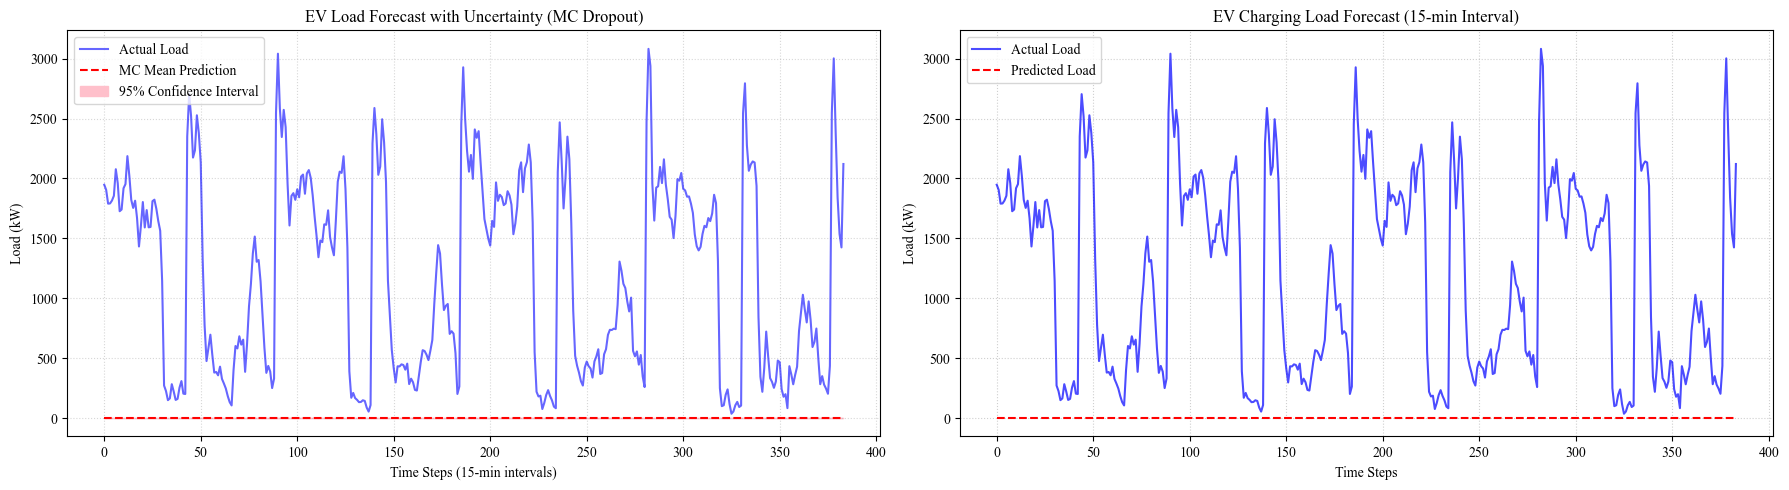

In [11]:
# ============================================
# 10. 可视化 — 整体预测 vs 实际（前384步）
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# 左图：带置信区间的 MC 预测
show_len = 384
time_axis = range(show_len)
axes[0].plot(time_axis, y_test_real[:show_len], label='Actual Load', color='blue', alpha=0.6)
axes[0].plot(time_axis, y_pred_real[:show_len], label='MC Mean Prediction', color='red', linestyle='--')
lower_bound = (y_pred_real - 1.96 * y_std_real).flatten()[:show_len]
upper_bound = (y_pred_real + 1.96 * y_std_real).flatten()[:show_len]
axes[0].fill_between(time_axis, lower_bound, upper_bound, color='pink', alpha=1.0,
                     label='95% Confidence Interval')
axes[0].set_title('EV Load Forecast with Uncertainty (MC Dropout)')
axes[0].set_xlabel('Time Steps (15-min intervals)')
axes[0].set_ylabel('Load (kW)')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.5)

# 右图：简洁预测对比
axes[1].plot(y_test_real[:384], label='Actual Load', color='blue', alpha=0.7)
axes[1].plot(y_pred_real[:384], label='Predicted Load', color='red', linestyle='--')
axes[1].set_title('EV Charging Load Forecast (15-min Interval)')
axes[1].set_xlabel('Time Steps')
axes[1].set_ylabel('Load (kW)')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Selected day for detailed plot: 2026-01-25


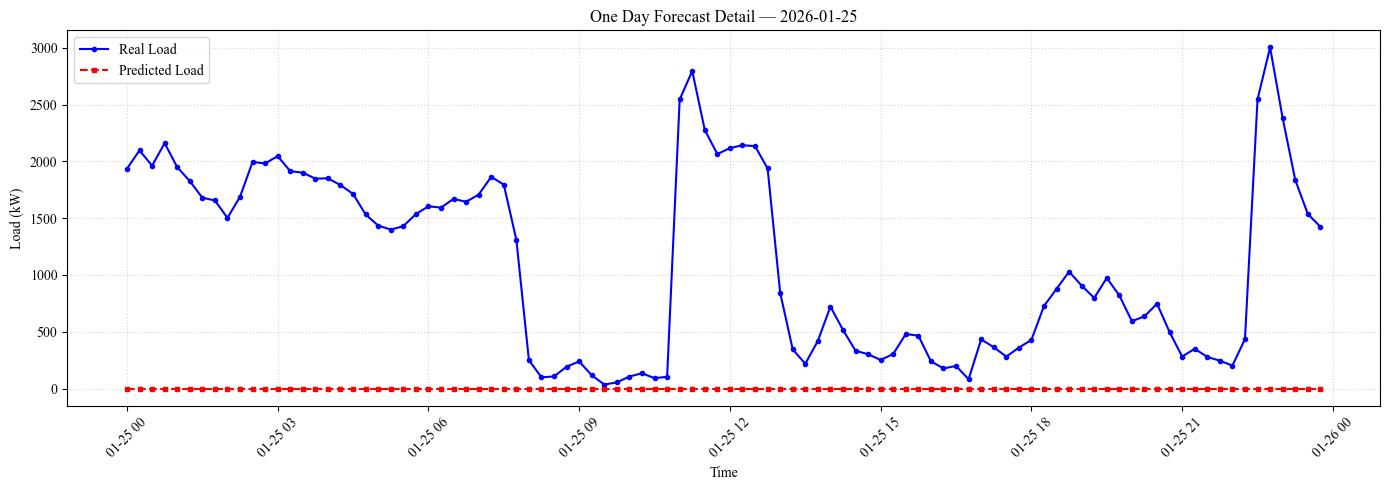

In [12]:
# ============================================
# 11. 可视化 — 单日细节
# ============================================
ONEDAY = 3  # 选择第几天（0-9），可修改

time_test = timestamp_test.iloc[-len(y_test_real):]
result = pd.DataFrame({
    "time": time_test.values,
    "real": y_test_real.flatten(),
    "pred": y_pred_real.flatten()
})
result["date"] = pd.to_datetime(result["time"]).dt.date

one_day = result["date"].iloc[ONEDAY * 96]
print(f"Selected day for detailed plot: {one_day}")

day_data = result[result["date"] == one_day]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(day_data["time"], day_data["real"], label="Real Load", color='blue', marker='o', markersize=3)
ax.plot(day_data["time"], day_data["pred"], label="Predicted Load", color='red', linestyle='--', marker='s', markersize=3)
ax.set_title(f"One Day Forecast Detail — {one_day}")
ax.set_xlabel("Time")
ax.set_ylabel("Load (kW)")
ax.legend()
ax.grid(True, linestyle=':', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

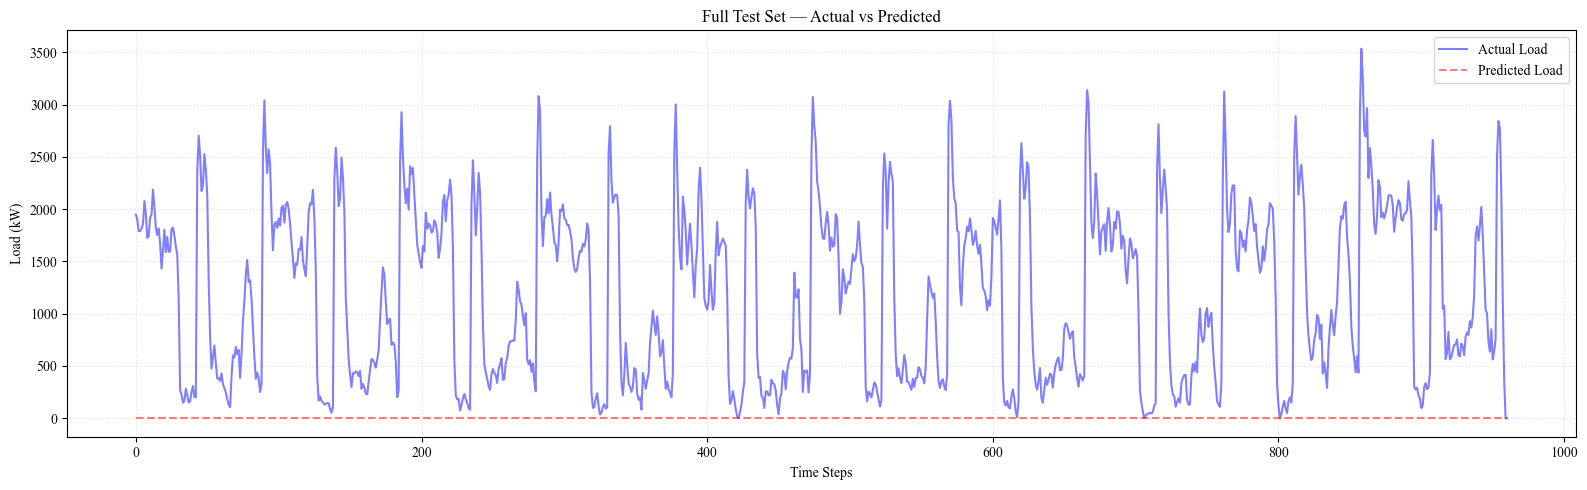

In [13]:
# ============================================
# 12. 可视化 — 全测试集概览
# ============================================
plt.figure(figsize=(16, 5))
plt.plot(y_test_real, label="Actual Load", color='blue', alpha=0.5)
plt.plot(y_pred_real, label="Predicted Load", color='red', alpha=0.5, linestyle='--')
plt.title("Full Test Set — Actual vs Predicted")
plt.xlabel("Time Steps")
plt.ylabel("Load (kW)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()